# Final Python Notebook 2: Classification Modelling & Hyperparameters Tuning
**Module:** 5DATA002W.2 Machine Learning & Data Mining  
**Author:** REPLACE_WITH_YOUR_FULL_NAME  
**reviewer:** REPLACE_WITH_PEER_FULL_NAME  
**date:** REPLACE_WITH_DATE  
**Dataset Used:** subset1_classification.csv (produced in Python Notebook 1)  
**Purpose:** Build, evaluate and optimise Naïve Bayes, Logistic Regression and K-Nearest Neighbours classifiers to predict Loan Approval Status.

## 1. Import Libraries
**Code Block Leveraged From:** Classification Modelling and Hyperparameter Optimisation

In [ ]:
# Import core libraries for modelling and evaluation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, recall_score,
    precision_score, f1_score, accuracy_score, roc_auc_score, roc_curve
)

sns.set_style('whitegrid')
print('Libraries loaded successfully.')


Libraries loaded successfully.


## 1b. External code declaration (coursework item 5)
**Code Block Leveraged From:** Classification Modelling and Hyperparameter Optimisation / module seminar materials

Code uses **Python**, **NumPy**, **pandas**, **Matplotlib**, **Seaborn**, and **scikit-learn** only. **No additional external code** requiring tutor approval is included.


## 2. Load Classification Dataset (Subset 1)
**Code Block Leveraged From:** Classification Modelling and Hyperparameter Optimisation

In [ ]:
# Load Subset 1 (Classification dataset) produced from Python Notebook 1
df = pd.read_csv('subset1_classification.csv')

# Display the shape of the dataset to confirm it loaded correctly
print("Dataset Shape (rows, columns):", df.shape)

# Display the first 5 rows to inspect the data
df.head()

Dataset Shape (rows, columns): (58638, 11)


,age,income,home_ownership_enc,emplyment_length,loan_intent_enc,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_enc,credit_history_length,loan_approval_status
0,40.0,182004,3,3,1,35000,8.00,0.19,0,11,0
1,40.0,90000,0,3,2,35000,12.42,0.39,0,14,0
2,40.0,131004,0,9,5,30000,7.90,0.23,0,13,0
3,40.0,150000,0,9,0,25000,11.89,0.17,0,11,0
4,40.0,132000,0,3,2,25000,16.82,0.22,0,17,0


In [ ]:
# Display the list of all feature names in the dataset
print("Feature Names:")
# Print output to the notebook cell result
print(df.columns.tolist())

# Display the data shape separately for report evidence (Task 4b.i)
print("\nData Shape:", df.shape)


Feature Names:
['age', 'income', 'home_ownership_enc', 'emplyment_length', 'loan_intent_enc', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_enc', 'credit_history_length', 'loan_approval_status']

Data Shape: (58638, 11)


## 3. Define Input Features (X) and Target Variable (y)
**Code Block Leveraged From:** Classification Modelling and Hyperparameter Optimisation

In [ ]:
# Separate input features (X) by dropping the target column
X = df.drop('loan_approval_status', axis=1)

# Define the target variable (y) - what we want to predict
y = df['loan_approval_status']

# Print feature names used for classification modelling (evidence for Task 4b.i)
print("Input Feature Names Used for Classification:")
# Print output to the notebook cell result
print(X.columns.tolist())

# Display the shape of X and y
print("\nX shape (features):", X.shape)
# Print output to the notebook cell result
print("y shape (target):", y.shape)

# Display target class distribution
print("\nTarget Variable Distribution (loan_approval_status):")
# Print output to the notebook cell result
print(y.value_counts())
# Print output to the notebook cell result
print(f"Rejected (0): {(y==0).sum():,} ({(y==0).sum()/len(y)*100:.1f}%)")
# Print output to the notebook cell result
print(f"Approved (1): {(y==1).sum():,} ({(y==1).sum()/len(y)*100:.1f}%)")


Input Feature Names Used for Classification:
['age', 'income', 'home_ownership_enc', 'emplyment_length', 'loan_intent_enc', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_enc', 'credit_history_length']

X shape (features): (58638, 10)
y shape (target): (58638,)

Target Variable Distribution (loan_approval_status):
loan_approval_status
0    50289
1     8349
Name: count, dtype: int64
Rejected (0): 50,289 (85.8%)
Approved (1): 8,349 (14.2%)


## 4. Train–Test Split
**Code Block Leveraged From:** Classification Modelling and Hyperparameter Optimisation

An **80/20 split** is used (80% training, 20% testing). Two key parameters ensure fair and consistent evaluation:
- `random_state=42`: Ensures **all three models are tested on the exact same test instances** (reproducibility).
- `stratify=y`: Ensures the **Approved/Rejected ratio is preserved** in both training and test subsets, which is critical given the class imbalance (85.8% Rejected vs 14.2% Approved).

In [ ]:
# Split the dataset into training (80%) and testing (20%) subsets
# random_state=42 ensures reproducibility - all models are tested on the same test instances
# stratify=y ensures the class ratio is preserved in both train and test subsets
X_train, X_test, y_train, y_test = train_test_split(
# Execute this statement as part of the analysis pipeline
    X, y,
# Assign into `test_size`
    test_size=0.2,       # 20% held out for testing
# Assign into `random_state`
    random_state=42,     # Fixed seed: ensures all models share same test set
# Assign into `stratify`
    stratify=y           # Preserves class distribution (Approved/Rejected ratio)
# Literal or closing token continuing the expression
)

# Display resulting split sizes
print(f"Training set size: {X_train.shape}")
# Print output to the notebook cell result
print(f"Test set size    : {X_test.shape}")

# Verify stratification: check class distribution in train and test
print("\nTraining Target Distribution:")
# Print output to the notebook cell result
print(y_train.value_counts())
# Print output to the notebook cell result
print(f"Rejected: {(y_train==0).sum()/len(y_train)*100:.1f}%  |  Approved: {(y_train==1).sum()/len(y_train)*100:.1f}%")
# Print output to the notebook cell result
print("\nTest Target Distribution:")
# Print output to the notebook cell result
print(y_test.value_counts())
# Print output to the notebook cell result
print(f"Rejected: {(y_test==0).sum()/len(y_test)*100:.1f}%  |  Approved: {(y_test==1).sum()/len(y_test)*100:.1f}%")


Training set size: (46910, 10)
Test set size    : (11728, 10)

Training Target Distribution:
loan_approval_status
0    40231
1     6679
Name: count, dtype: int64
Rejected: 85.8%  |  Approved: 14.2%

Test Target Distribution:
loan_approval_status
0    10058
1     1670
Name: count, dtype: int64
Rejected: 85.8%  |  Approved: 14.2%


## 5. Feature Scaling (StandardScaler)
**Code Block Leveraged From:** Classification Modelling and Hyperparameter Optimisation

StandardScaler is applied for **Logistic Regression and KNN**, which are sensitive to feature magnitude. Naïve Bayes does not require scaling as it models each feature independently using probability distributions.

In [ ]:
# Initialise StandardScaler to standardise features to zero mean and unit variance
scaler = StandardScaler()

# Fit the scaler on training data only, then transform both train and test sets
# Note: scaler is ONLY fitted on training data to prevent data leakage from test set
X_train_scaled = scaler.fit_transform(X_train)
# Assign into `X_test_scaled`
X_test_scaled  = scaler.transform(X_test)
# Print output to the notebook cell result
print("Feature scaling applied successfully.")
# Print output to the notebook cell result
print("Scaled X_train shape:", X_train_scaled.shape)
# Print output to the notebook cell result
print("Scaled X_test shape :", X_test_scaled.shape)


Feature scaling applied successfully.
Scaled X_train shape: (46910, 10)
Scaled X_test shape : (11728, 10)


## 6. Build Classification Models
**Code Block Leveraged From:** Classification Modelling and Hyperparameter Optimisation

### 6.1 Model 1: Naïve Bayes (NB)

In [ ]:
# Declare and initialise the Gaussian Naïve Bayes classifier
# GaussianNB is used as the input features are continuous (numeric)
nb_model = GaussianNB()

# Fit (train) the Naïve Bayes model on the UNSCALED training data
# NB does not require feature scaling as it models each feature independently
nb_model.fit(X_train, y_train)
# Print output to the notebook cell result
print("Naïve Bayes model trained successfully.")

# Generate predictions on the test set
y_pred_nb = nb_model.predict(X_test)

# Generate predicted class probabilities (needed for AUC-ROC)
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]
# Print output to the notebook cell result
print("Predictions generated.")


Naïve Bayes model trained successfully.
Predictions generated.


### 6.2 Model 2: Logistic Regression (LR)

In [ ]:
# Declare and initialise the Logistic Regression classifier
# random_state=42 ensures reproducibility; max_iter=1000 ensures convergence
lr_model = LogisticRegression(random_state=42, max_iter=1000)

# Fit the Logistic Regression model on the SCALED training data
# LR requires scaled features as it is sensitive to feature magnitude
lr_model.fit(X_train_scaled, y_train)
# Print output to the notebook cell result
print("Logistic Regression model trained successfully.")

# Generate predictions on the SCALED test set
y_pred_lr = lr_model.predict(X_test_scaled)

# Generate predicted class probabilities for AUC-ROC
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
# Print output to the notebook cell result
print("Predictions generated.")


Logistic Regression model trained successfully.
Predictions generated.


### 6.3 Model 3: K-Nearest Neighbours (KNN)

In [ ]:
# Explore different values of K to identify the best K by recall score
# Recall is the key metric based on the success criteria (maximise correct reject detection)
print("K-value Exploration by Recall Score:")
# Print output to the notebook cell result
print("-" * 35)
# Assign into `k_recall_scores`
k_recall_scores = []
# Loop header iterating or repeating a block
for k in range(3, 21, 2):
    # Declare KNN model with current k value
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    # Fit on scaled training data
    knn_temp.fit(X_train_scaled, y_train)
    # Predict on scaled test data
    y_pred_temp = knn_temp.predict(X_test_scaled)
    # Compute recall score for the Approved (1) class
    rec = recall_score(y_test, y_pred_temp)
# Execute this statement as part of the analysis pipeline
    k_recall_scores.append((k, round(rec, 4)))
# Print output to the notebook cell result
    print(f"  K={k:>2d}  |  Recall = {rec:.4f}")

# Select the K with the highest recall
best_k = max(k_recall_scores, key=lambda x: x[1])[0]
# Print output to the notebook cell result
print(f"\nSelected K = {best_k} (highest recall)") 


K-value Exploration by Recall Score:
-----------------------------------


  K= 3  |  Recall = 0.5527


  K= 5  |  Recall = 0.5401


  K= 7  |  Recall = 0.5263


  K= 9  |  Recall = 0.5216


  K=11  |  Recall = 0.5162


  K=13  |  Recall = 0.5006


  K=15  |  Recall = 0.4910


  K=17  |  Recall = 0.4898


  K=19  |  Recall = 0.4814

Selected K = 3 (highest recall)


In [ ]:
# Declare and initialise the KNN classifier with the best K found above
knn_model = KNeighborsClassifier(n_neighbors=3)

# Fit the KNN model on the SCALED training data
# KNN is a distance-based algorithm and requires feature scaling
knn_model.fit(X_train_scaled, y_train)
# Print output to the notebook cell result
print("KNN model (K=3) trained successfully.")

# Generate predictions on the SCALED test set
y_pred_knn = knn_model.predict(X_test_scaled)

# Generate predicted class probabilities for AUC-ROC
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]
# Print output to the notebook cell result
print("Predictions generated.")


KNN model (K=3) trained successfully.


Predictions generated.


## 7. Evaluate All Classification Models
**Code Block Leveraged From:** Classification Modelling and Hyperparameter Optimisation

### 7.1 Confusion Matrices

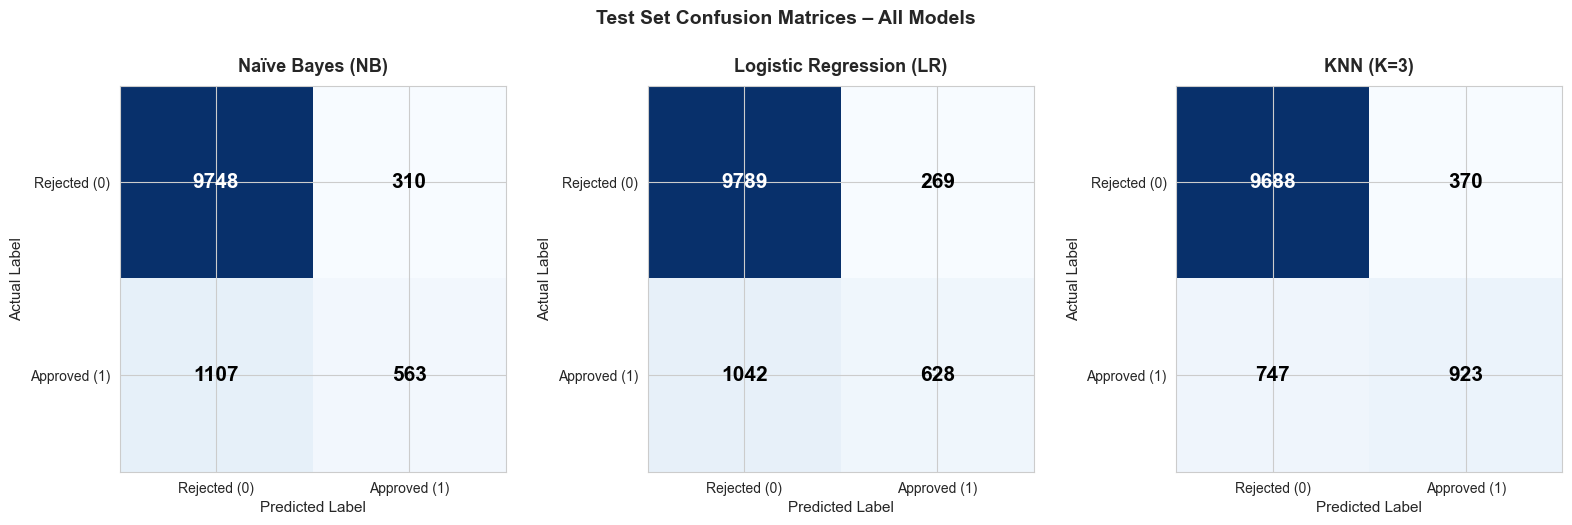

In [ ]:
# Plot confusion matrices for all three models side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# Assign into `model_info`
model_info = [
# Execute this statement as part of the analysis pipeline
    ('Naïve Bayes (NB)',         y_pred_nb),
# Execute this statement as part of the analysis pipeline
    ('Logistic Regression (LR)', y_pred_lr),
# Execute this statement as part of the analysis pipeline
    ('KNN (K=3)',                 y_pred_knn),
# Literal or closing token continuing the expression
]
# Loop header iterating or repeating a block
for ax, (title, y_pred) in zip(axes, model_info):
    # Compute confusion matrix for current model
    cm = confusion_matrix(y_test, y_pred)
    # Plot heatmap of confusion matrix
    im = ax.imshow(cm, cmap='Blues')
# Configure matplotlib axes property
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
# Configure matplotlib axes property
    ax.set_xlabel('Predicted Label', fontsize=11)
# Configure matplotlib axes property
    ax.set_ylabel('Actual Label', fontsize=11)
# Configure matplotlib axes property
    ax.set_xticks([0, 1])
# Configure matplotlib axes property
    ax.set_yticks([0, 1])
# Configure matplotlib axes property
    ax.set_xticklabels(['Rejected (0)', 'Approved (1)'], fontsize=10)
# Configure matplotlib axes property
    ax.set_yticklabels(['Rejected (0)', 'Approved (1)'], fontsize=10)
    # Annotate each cell with its count value
    for i in range(2):
# Loop header iterating or repeating a block
        for j in range(2):
# Draw on matplotlib axes
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
# Assign into `fontsize`
                    fontsize=15, fontweight='bold',
# Assign into `color`
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
# Call pyplot function for figure or layout
plt.suptitle('Test Set Confusion Matrices – All Models', fontsize=14, fontweight='bold', y=1.02)
# Call pyplot function for figure or layout
plt.tight_layout()
# Call pyplot function for figure or layout
plt.show()


### 7.2 Classification Reports

In [ ]:
# Print the full classification report for each model
# Reports include precision, recall, f1-score and support for each class
print("=" * 55)
# Print output to the notebook cell result
print("NAÏVE BAYES (NB) – Classification Report")
# Print output to the notebook cell result
print("=" * 55)
# Print output to the notebook cell result
print(classification_report(y_test, y_pred_nb, target_names=['Rejected (0)', 'Approved (1)']))
# Print output to the notebook cell result
print("=" * 55)
# Print output to the notebook cell result
print("LOGISTIC REGRESSION (LR) – Classification Report")
# Print output to the notebook cell result
print("=" * 55)
# Print output to the notebook cell result
print(classification_report(y_test, y_pred_lr, target_names=['Rejected (0)', 'Approved (1)']))
# Print output to the notebook cell result
print("=" * 55)
# Print output to the notebook cell result
print("KNN (K=3) – Classification Report")
# Print output to the notebook cell result
print("=" * 55)
# Print output to the notebook cell result
print(classification_report(y_test, y_pred_knn, target_names=['Rejected (0)', 'Approved (1)']))


NAÏVE BAYES (NB) – Classification Report
              precision    recall  f1-score   support

Rejected (0)       0.90      0.97      0.93     10058
Approved (1)       0.64      0.34      0.44      1670

    accuracy                           0.88     11728
   macro avg       0.77      0.65      0.69     11728
weighted avg       0.86      0.88      0.86     11728

LOGISTIC REGRESSION (LR) – Classification Report
              precision    recall  f1-score   support

Rejected (0)       0.90      0.97      0.94     10058
Approved (1)       0.70      0.38      0.49      1670

    accuracy                           0.89     11728
   macro avg       0.80      0.67      0.71     11728
weighted avg       0.87      0.89      0.87     11728

KNN (K=3) – Classification Report
              precision    recall  f1-score   support

Rejected (0)       0.93      0.96      0.95     10058
Approved (1)       0.71      0.55      0.62      1670

    accuracy                           0.90     11728
   m

### 7.3 AUC-ROC Curves

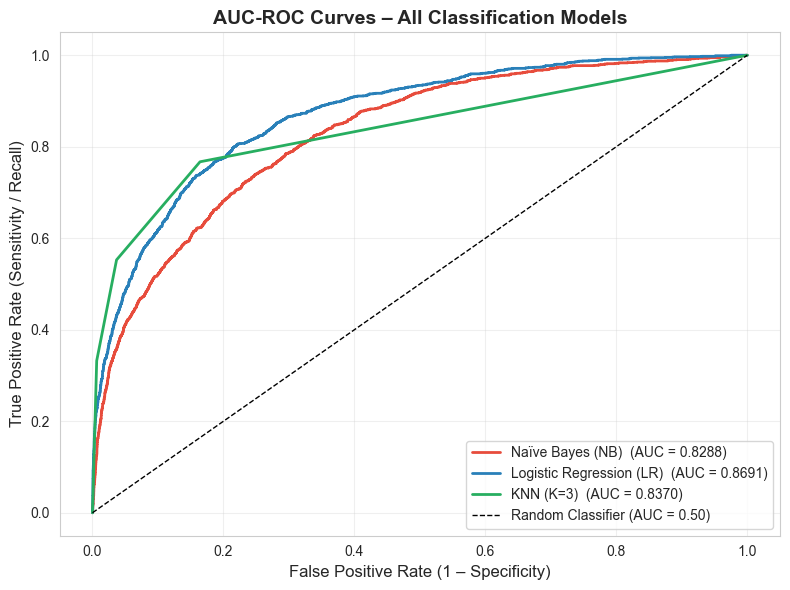

In [ ]:
# Plot AUC-ROC curves for all three models on a single graph
fig, ax = plt.subplots(figsize=(8, 6))

# Define colour for each model
model_roc_info = [
# Execute this statement as part of the analysis pipeline
    ('Naïve Bayes (NB)',         y_prob_nb,  '#E74C3C'),
# Execute this statement as part of the analysis pipeline
    ('Logistic Regression (LR)', y_prob_lr,  '#2980B9'),
# Execute this statement as part of the analysis pipeline
    ('KNN (K=3)',                 y_prob_knn, '#27AE60'),
# Literal or closing token continuing the expression
]
# Loop header iterating or repeating a block
for label, y_prob, color in model_roc_info:
    # Compute FPR, TPR at various thresholds
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    # Compute AUC-ROC score
    auc = roc_auc_score(y_test, y_prob)
# Call axes method for the current subplot
    ax.plot(fpr, tpr, label=f'{label}  (AUC = {auc:.4f})', color=color, lw=2)

# Plot diagonal reference line (random classifier)
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC = 0.50)')
# Configure matplotlib axes property
ax.set_xlabel('False Positive Rate (1 – Specificity)', fontsize=12)
# Configure matplotlib axes property
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
# Configure matplotlib axes property
ax.set_title('AUC-ROC Curves – All Classification Models', fontsize=14, fontweight='bold')
# Call axes method for the current subplot
ax.legend(fontsize=10, loc='lower right')
# Call axes method for the current subplot
ax.grid(alpha=0.3)
# Call pyplot function for figure or layout
plt.tight_layout()
# Call pyplot function for figure or layout
plt.show()


### 7.4 Summary of All Evaluation Metric Scores

In [ ]:
# Compute and display all five evaluation metrics for each model
print(f"{'Metric':<15} {'NB':>10} {'LR':>10} {'KNN (K=3)':>12}")
# Print output to the notebook cell result
print("-" * 50)
# Assign into `metrics`
metrics = {
# String element inside a collection or call
    'Accuracy' : [accuracy_score,  [y_test, y_pred_nb],  [y_test, y_pred_lr],  [y_test, y_pred_knn]],
# String element inside a collection or call
    'Recall'   : [recall_score,    [y_test, y_pred_nb],  [y_test, y_pred_lr],  [y_test, y_pred_knn]],
# String element inside a collection or call
    'Precision': [precision_score, [y_test, y_pred_nb],  [y_test, y_pred_lr],  [y_test, y_pred_knn]],
# String element inside a collection or call
    'F1-Score' : [f1_score,        [y_test, y_pred_nb],  [y_test, y_pred_lr],  [y_test, y_pred_knn]],
# String element inside a collection or call
    'AUC-ROC'  : [roc_auc_score,   [y_test, y_prob_nb],  [y_test, y_prob_lr],  [y_test, y_prob_knn]],
# Literal or closing token continuing the expression
}
# Loop header iterating or repeating a block
for name, (fn, a1, a2, a3) in metrics.items():
# Assign into `s1`
    s1 = round(fn(*a1), 4)
# Assign into `s2`
    s2 = round(fn(*a2), 4)
# Assign into `s3`
    s3 = round(fn(*a3), 4)
# Print output to the notebook cell result
    print(f"{name:<15} {s1:>10.4f} {s2:>10.4f} {s3:>12.4f}")


Metric                  NB         LR    KNN (K=3)
--------------------------------------------------
Accuracy            0.8792     0.8882       0.9048


Recall              0.3371     0.3760       0.5527
Precision           0.6449     0.7001       0.7138
F1-Score            0.4428     0.4893       0.6230
AUC-ROC             0.8288     0.8691       0.8370


## 8. Hyperparameter Tuning – Best Model (KNN) with GridSearchCV
**Code Block Leveraged From:** Classification Modelling and Hyperparameter Optimisation

**KNN** was selected as the best model based on **test recall** (highest among the three baseline models). This aligns with the success criteria, which prioritise correctly detecting (predicting) rejected applications. **GridSearchCV** with 5-fold cross-validation is applied to tune three KNN hyperparameters: `n_neighbors`, `weights`, and `metric`. After you run the notebook, use the printed recall values in your Word report.

In [ ]:
# Define the hyperparameter grid to search over for KNN
# n_neighbors: number of nearest neighbours to consider
# weights: how to weight neighbours (uniform = equal, distance = closer neighbours weighted more)
# metric: distance measure used (euclidean or manhattan)
param_grid = {
# String element inside a collection or call
    'n_neighbors': [3, 5, 7, 9, 11],
# String element inside a collection or call
    'weights'    : ['uniform', 'distance'],
# String element inside a collection or call
    'metric'     : ['euclidean', 'manhattan']
# Literal or closing token continuing the expression
}

# Initialise GridSearchCV with 5-fold cross-validation
# scoring='recall' aligns with the success criteria (maximise correct rejection detection)
grid_search = GridSearchCV(
# Assign into `estimator`
    estimator=KNeighborsClassifier(),
# Reference GridSearchCV object or its parameter grid
    param_grid=param_grid,
# Assign into `cv`
    cv=5,
# Assign into `scoring`
    scoring='recall',
# Assign into `n_jobs`
    n_jobs=-1,
# Assign into `verbose`
    verbose=1
# Literal or closing token continuing the expression
)

# Fit GridSearchCV on the scaled training data
grid_search.fit(X_train_scaled, y_train)

# Display the best hyperparameters found
print("\nBest Hyperparameters Found by GridSearchCV:")
# Print output to the notebook cell result
print(grid_search.best_params_)
# Print output to the notebook cell result
print(f"\nBest Cross-Validated Recall Score: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits



Best Hyperparameters Found by GridSearchCV:
{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}

Best Cross-Validated Recall Score: 0.5514


In [ ]:
# Extract the best estimator (model with optimal hyperparameters)
knn_tuned = grid_search.best_estimator_

# Generate predictions using the tuned KNN model
y_pred_knn_tuned = knn_tuned.predict(X_test_scaled)

# Generate predicted probabilities for AUC-ROC
y_prob_knn_tuned = knn_tuned.predict_proba(X_test_scaled)[:, 1]
# Print output to the notebook cell result
print("Tuned KNN model evaluated on test set.")
# Print output to the notebook cell result
print("\nClassification Report – Tuned KNN:")
# Print output to the notebook cell result
print(classification_report(y_test, y_pred_knn_tuned, target_names=['Rejected (0)', 'Approved (1)']))


Tuned KNN model evaluated on test set.

Classification Report – Tuned KNN:
              precision    recall  f1-score   support

Rejected (0)       0.93      0.96      0.95     10058
Approved (1)       0.71      0.56      0.62      1670

    accuracy                           0.90     11728
   macro avg       0.82      0.76      0.78     11728
weighted avg       0.90      0.90      0.90     11728



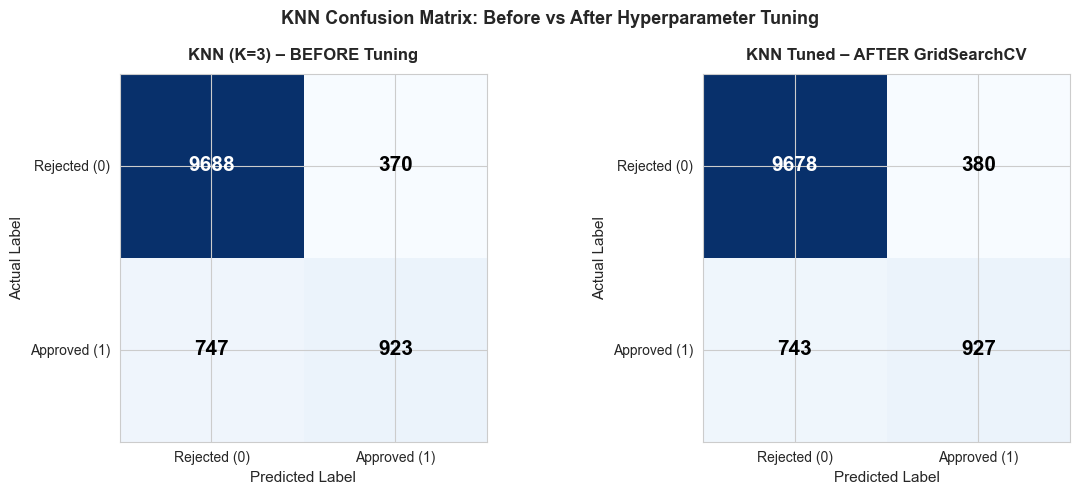

In [ ]:
# Plot confusion matrices BEFORE and AFTER hyperparameter tuning for comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Assign into `cm_pairs`
cm_pairs = [
# Execute this statement as part of the analysis pipeline
    (confusion_matrix(y_test, y_pred_knn),       'KNN (K=3) – BEFORE Tuning'),
# Execute this statement as part of the analysis pipeline
    (confusion_matrix(y_test, y_pred_knn_tuned), 'KNN Tuned – AFTER GridSearchCV'),
# Literal or closing token continuing the expression
]
# Loop header iterating or repeating a block
for ax, (cm, title) in zip(axes, cm_pairs):
# Draw on matplotlib axes
    ax.imshow(cm, cmap='Blues')
# Configure matplotlib axes property
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
# Configure matplotlib axes property
    ax.set_xlabel('Predicted Label', fontsize=11)
# Configure matplotlib axes property
    ax.set_ylabel('Actual Label', fontsize=11)
# Configure matplotlib axes property
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
# Configure matplotlib axes property
    ax.set_xticklabels(['Rejected (0)', 'Approved (1)'])
# Configure matplotlib axes property
    ax.set_yticklabels(['Rejected (0)', 'Approved (1)'])
# Loop header iterating or repeating a block
    for i in range(2):
# Loop header iterating or repeating a block
        for j in range(2):
# Draw on matplotlib axes
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
# Assign into `fontsize`
                    fontsize=15, fontweight='bold',
# Assign into `color`
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
# Call pyplot function for figure or layout
plt.suptitle('KNN Confusion Matrix: Before vs After Hyperparameter Tuning', fontsize=13, fontweight='bold')
# Call pyplot function for figure or layout
plt.tight_layout()
# Call pyplot function for figure or layout
plt.show()


In [ ]:
# Compare key metrics before and after tuning
print("=" * 55)
# Print output to the notebook cell result
print("PERFORMANCE COMPARISON – KNN Before vs After Tuning")
# Print output to the notebook cell result
print("=" * 55)
# Print output to the notebook cell result
print(f"{'Metric':<15} {'Before':>10} {'After (Tuned)':>15}")
# Print output to the notebook cell result
print("-" * 45)
# Assign into `metric_pairs`
metric_pairs = [
# Execute this statement as part of the analysis pipeline
    ('Accuracy',  accuracy_score(y_test, y_pred_knn),       accuracy_score(y_test, y_pred_knn_tuned)),
# Execute this statement as part of the analysis pipeline
    ('Recall',    recall_score(y_test, y_pred_knn),          recall_score(y_test, y_pred_knn_tuned)),
# Execute this statement as part of the analysis pipeline
    ('Precision', precision_score(y_test, y_pred_knn),       precision_score(y_test, y_pred_knn_tuned)),
# Execute this statement as part of the analysis pipeline
    ('F1-Score',  f1_score(y_test, y_pred_knn),              f1_score(y_test, y_pred_knn_tuned)),
# Execute this statement as part of the analysis pipeline
    ('AUC-ROC',   roc_auc_score(y_test, y_prob_knn),         roc_auc_score(y_test, y_prob_knn_tuned)),
# Literal or closing token continuing the expression
]
# Loop header iterating or repeating a block
for name, before, after in metric_pairs:
# Assign into `diff`
    diff = after - before
# Assign into `direction`
    direction = "↑" if diff > 0 else ("↓" if diff < 0 else "–")
# Print output to the notebook cell result
    print(f"{name:<15} {before:>10.4f} {after:>15.4f}  {direction} ({diff:+.4f})")


PERFORMANCE COMPARISON – KNN Before vs After Tuning
Metric              Before   After (Tuned)
---------------------------------------------
Accuracy            0.9048          0.9042  ↓ (-0.0005)
Recall              0.5527          0.5551  ↑ (+0.0024)
Precision           0.7138          0.7093  ↓ (-0.0046)
F1-Score            0.6230          0.6228  ↓ (-0.0002)
AUC-ROC             0.8370          0.8390  ↑ (+0.0020)


## 9. Summary
**Code Block Leveraged From:** Classification Modelling and Hyperparameter Optimisation

In [ ]:
# Final summary of all model performances
print("=" * 65)
# Print output to the notebook cell result
print("FINAL MODEL PERFORMANCE SUMMARY")
# Print output to the notebook cell result
print("=" * 65)
# Assign into `summary_data`
summary_data = {
# String element inside a collection or call
    'Model'    : ['Naïve Bayes (NB)', 'Logistic Regression (LR)', 'KNN (K=3)', 'KNN Tuned'],
# String element inside a collection or call
    'Accuracy' : [
# Execute this statement as part of the analysis pipeline
        round(accuracy_score(y_test, y_pred_nb), 4),
# Execute this statement as part of the analysis pipeline
        round(accuracy_score(y_test, y_pred_lr), 4),
# Execute this statement as part of the analysis pipeline
        round(accuracy_score(y_test, y_pred_knn), 4),
# Execute this statement as part of the analysis pipeline
        round(accuracy_score(y_test, y_pred_knn_tuned), 4)
# Literal or closing token continuing the expression
    ],
# String element inside a collection or call
    'Recall'   : [
# Execute this statement as part of the analysis pipeline
        round(recall_score(y_test, y_pred_nb), 4),
# Execute this statement as part of the analysis pipeline
        round(recall_score(y_test, y_pred_lr), 4),
# Execute this statement as part of the analysis pipeline
        round(recall_score(y_test, y_pred_knn), 4),
# Execute this statement as part of the analysis pipeline
        round(recall_score(y_test, y_pred_knn_tuned), 4)
# Literal or closing token continuing the expression
    ],
# String element inside a collection or call
    'Precision': [
# Execute this statement as part of the analysis pipeline
        round(precision_score(y_test, y_pred_nb), 4),
# Execute this statement as part of the analysis pipeline
        round(precision_score(y_test, y_pred_lr), 4),
# Execute this statement as part of the analysis pipeline
        round(precision_score(y_test, y_pred_knn), 4),
# Execute this statement as part of the analysis pipeline
        round(precision_score(y_test, y_pred_knn_tuned), 4)
# Literal or closing token continuing the expression
    ],
# String element inside a collection or call
    'F1-Score' : [
# Execute this statement as part of the analysis pipeline
        round(f1_score(y_test, y_pred_nb), 4),
# Execute this statement as part of the analysis pipeline
        round(f1_score(y_test, y_pred_lr), 4),
# Execute this statement as part of the analysis pipeline
        round(f1_score(y_test, y_pred_knn), 4),
# Execute this statement as part of the analysis pipeline
        round(f1_score(y_test, y_pred_knn_tuned), 4)
# Literal or closing token continuing the expression
    ],
# String element inside a collection or call
    'AUC-ROC'  : [
# Execute this statement as part of the analysis pipeline
        round(roc_auc_score(y_test, y_prob_nb), 4),
# Execute this statement as part of the analysis pipeline
        round(roc_auc_score(y_test, y_prob_lr), 4),
# Execute this statement as part of the analysis pipeline
        round(roc_auc_score(y_test, y_prob_knn), 4),
# Execute this statement as part of the analysis pipeline
        round(roc_auc_score(y_test, y_prob_knn_tuned), 4)
# Literal or closing token continuing the expression
    ],
# Literal or closing token continuing the expression
}
# Assign into `summary_df`
summary_df = pd.DataFrame(summary_data)
# Print output to the notebook cell result
print(summary_df.to_string(index=False))
# Print output to the notebook cell result
print(f"\nBest model by test recall (baseline): KNN (K=3) — recall = {recall_score(y_test, y_pred_knn):.4f}")
# Print output to the notebook cell result
print(f"After GridSearchCV tuning: KNN tuned — recall = {recall_score(y_test, y_pred_knn_tuned):.4f}")


FINAL MODEL PERFORMANCE SUMMARY


                   Model  Accuracy  Recall  Precision  F1-Score  AUC-ROC
        Naïve Bayes (NB)    0.8792  0.3371     0.6449    0.4428   0.8288
Logistic Regression (LR)    0.8882  0.3760     0.7001    0.4893   0.8691
               KNN (K=3)    0.9048  0.5527     0.7138    0.6230   0.8370
               KNN Tuned    0.9042  0.5551     0.7093    0.6228   0.8390

Best model by test recall (baseline): KNN (K=3) — recall = 0.5527
After GridSearchCV tuning: KNN tuned — recall = 0.5551
